In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
PALETTE      = {"Healthy": "#4dac26", "Unhealthy": "#d01c8b"}
COHORT_ORDER = ["Healthy", "Unhealthy"]

In [4]:
BASE_DIR  = "/Users/willtrim/Documents/projs/Wills_analysis/obesity_scRNAseq"

TISSUES = {
  "omentum": {
    "h5ad": "inputs/anndatas/omentum_reannotated_finely_truncated.h5ad",
    "de_file": "results/DE/omentum/MAST_results_per_cell_type_.csv",
    "part_col": "common_participant"
  },
  "subq": {
    "h5ad": "inputs/anndatas/sq_reannotated_finely_truncated.h5ad",
    "de_file": "results/DE/subq/MAST_results_per_cell_type_.csv",
    "part_col": "common_participant"
  }
}


## Distinguishing true OXPHOS/ribosome upregulation from library quality artifact

### Why the ambiguity exists
In dying or damaged cells, cytoplasmic mRNA degrades faster than mitochondrial mRNA → **MT%** rises.  
Ribosomal protein genes (RPS/RPL) are among the most highly expressed genes in any cell; if a cell loses cytoplasmic mRNA (poor viability), the **ribosomal fraction** can rise artifactually even if absolute ribosomal expression is unchanged.  
If the Unhealthy cohort had systematically worse cell viability at capture, you would see exactly what you observed in DE: OXPHOS and ribosome "up" in Unhealthy is actually healthy cells losing context.

### Decision tree

| Observation | Interpretation |
|---|---|
| Unhealthy has **higher median MT%** per participant (p < 0.05) | Library quality difference — artifact plausible |
| MT% and ribosome% **positively correlated within cells** across both cohorts | Same artifact: both elevated in compromised cells |
| QC metrics (n_genes, total counts) **lower in Unhealthy** | Consistent with lower-quality libraries |
| MT% difference **not significant**, no within-cell MT-RB correlation | More likely true biology |
| DE signal **survives regressing out MT%** as covariate | Strong evidence for true biology |

### Plots produced below
1. Participant-level QC metrics (MT%, RB%, n_genes, total counts) grouped by cohort — **the primary check**
2. Cell-level MT% vs ribosome% scatter per tissue — **the correlation check**
3. Cell-level distribution of MT% and RB% by cohort — complementary view

In [9]:
adata.X.sum(axis=0)

matrix([[ 15.372844 ,   1.2707771,  73.55595  , ..., 233.55353  ,
         142.94543  ,   2.2576406]], shape=(1, 26158), dtype=float32)


=== omentum ===
  25830 cells × 26158 genes
  MT genes: 13   |   RB genes (RPS/RPL): 96
   cohort  n_cells  pct_mt_median  pct_rb_median  n_genes_median
  Healthy     3563       6.344549      16.528378          1575.0
  Healthy     3769       8.364758      15.395247          1749.0
  Healthy     3722       7.377124      17.210190          1491.5
  Healthy     2790       9.415001      15.352769          1369.5
  Healthy      730       6.276276      16.713917          1542.0
Unhealthy     2124       8.324915      17.161634          2105.0
Unhealthy     2562       9.497707      23.403328          2705.0
Unhealthy     2342       6.143122      22.452904          2181.0
Unhealthy     2240       9.226797      22.307318          1864.5
Unhealthy     1988       7.888028      16.381430          1973.5


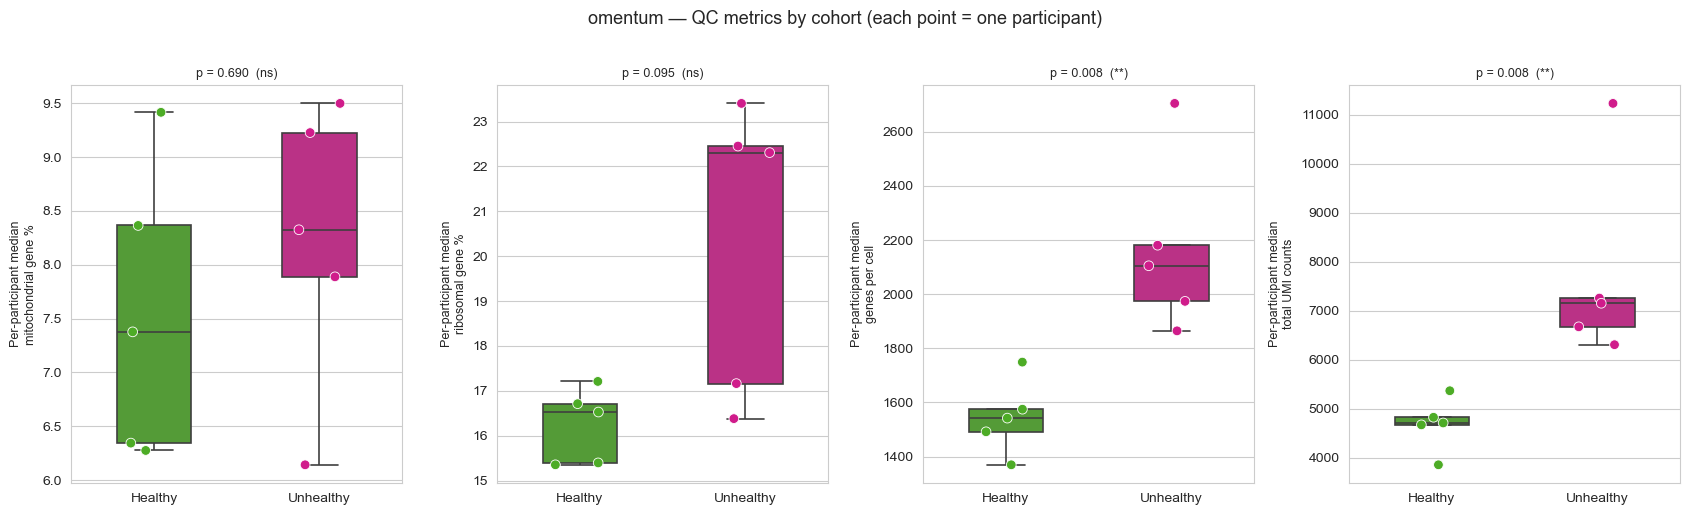


=== subq ===
  9127 cells × 22651 genes
  MT genes: 13   |   RB genes (RPS/RPL): 94
   cohort  n_cells  pct_mt_median  pct_rb_median  n_genes_median
  Healthy      356       6.509115      17.111984          1889.5
  Healthy      374       7.819632      14.817390          1875.5
  Healthy     1443       6.433145      15.497518          2148.0
  Healthy       80       9.169165      16.537022          1529.5
  Healthy      818       6.218409      15.783890          2179.0
Unhealthy      453       8.317815      12.620508          1958.0
Unhealthy     2623       8.426423      17.911552          2159.0
Unhealthy       62       6.895019      16.847017          1822.5
Unhealthy      811       7.359131      15.227663          1972.0
Unhealthy     2107       6.706114      15.250966          2113.0


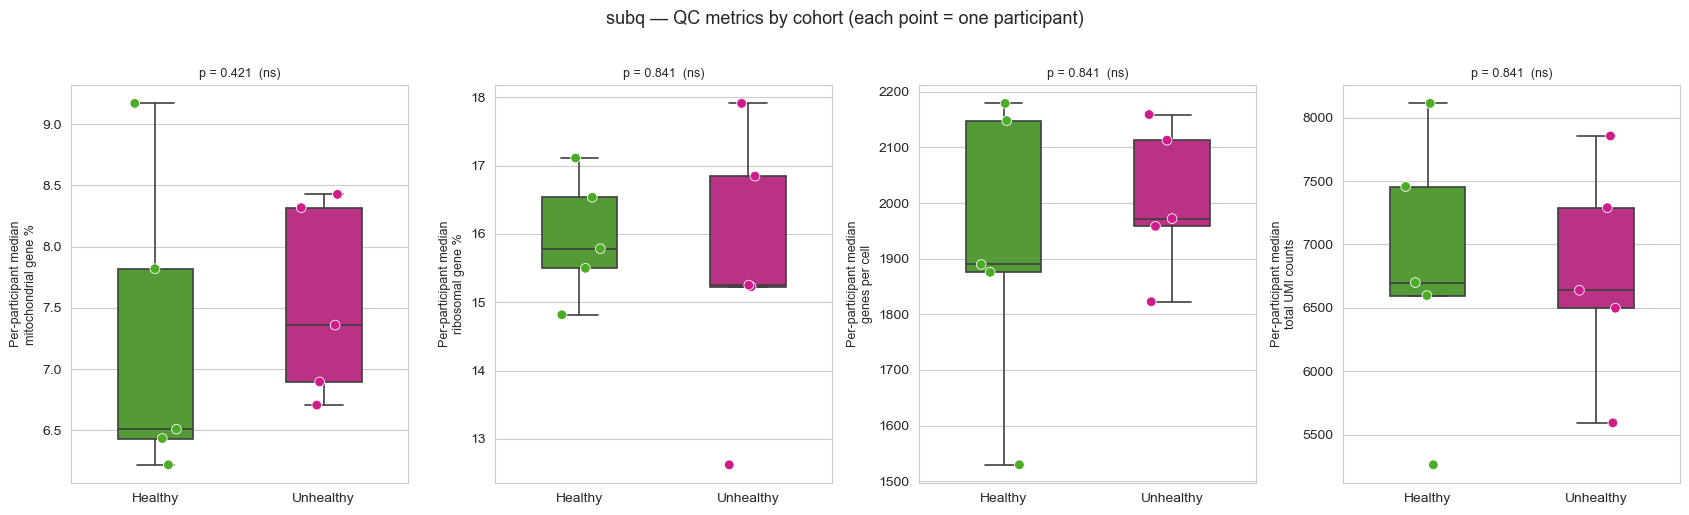

In [5]:
def compute_qc(adata, part_col, cohort_col="cohort"):
    """Mark MT/RB genes, compute QC metrics, return (cell-level obs df, per-participant df)."""
    adata.var["mt"] = adata.var_names.str.startswith("MT-")
    adata.var["rb"] = adata.var_names.str.match(r"^RP[SL]\d")
    sc.pp.calculate_qc_metrics(adata, layer="counts", qc_vars=["mt", "rb"],
                                percent_top=None, log1p=False, inplace=True)

    obs = adata.obs[[part_col, cohort_col,
                     "pct_counts_mt", "pct_counts_rb",
                     "n_genes_by_counts", "total_counts"]].copy()
    obs = obs.rename(columns={part_col: "participant", cohort_col: "cohort"})

    per_part = (obs.groupby("participant")
                .agg(cohort          = ("cohort",          "first"),
                     n_cells         = ("participant",      "count"),
                     pct_mt_median   = ("pct_counts_mt",   "median"),
                     pct_rb_median   = ("pct_counts_rb",   "median"),
                     n_genes_median  = ("n_genes_by_counts","median"),
                     total_ct_median = ("total_counts",    "median"))
                .reset_index())
    return obs, per_part


def mwu_label(a, b):
    _, p = stats.mannwhitneyu(a.dropna(), b.dropna(), alternative="two-sided")
    stars = "****" if p < 0.0001 else "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
    return f"p = {p:.3f}  ({stars})"


def plot_participant_qc(per_part, tissue):
    """4-panel boxplot+strip of per-participant QC metrics grouped by cohort."""
    metrics = [
        ("pct_mt_median",   "Median MT%",           "Per-participant median\nmitochondrial gene %"),
        ("pct_rb_median",   "Median ribosomal%",    "Per-participant median\nribosomal gene %"),
        ("n_genes_median",  "Median genes/cell",    "Per-participant median\ngenes per cell"),
        ("total_ct_median", "Median total counts",  "Per-participant median\ntotal UMI counts"),
    ]

    fig, axes = plt.subplots(1, 4, figsize=(17, 5))
    fig.suptitle(f"{tissue} — QC metrics by cohort (each point = one participant)", fontsize=13, y=1.02)

    for ax, (col, short, ylabel) in zip(axes, metrics):
        sns.boxplot(data=per_part, x="cohort", y=col, palette=PALETTE,
                    order=COHORT_ORDER, width=0.45, fliersize=0, linewidth=1.2, ax=ax)
        sns.stripplot(data=per_part, x="cohort", y=col, palette=PALETTE,
                      order=COHORT_ORDER, size=7, jitter=0.15, linewidth=0.6,
                      edgecolor="white", ax=ax)

        h = per_part.loc[per_part.cohort == "Healthy",   col]
        u = per_part.loc[per_part.cohort == "Unhealthy", col]
        label = mwu_label(h, u)
        ax.set_title(label, fontsize=9)
        ax.set_xlabel("")
        ax.set_ylabel(ylabel, fontsize=9)

    plt.tight_layout()
    plt.show()


# ── Main loop ──────────────────────────────────────────────────────────────────
obs_all = {}   # store cell-level obs for each tissue (used in next cell)

for tissue, cfg in TISSUES.items():
    import os
    h5ad_path = os.path.join(BASE_DIR, cfg["h5ad"])
    print(f"\n=== {tissue} ===")
    adata = sc.read_h5ad(h5ad_path)
    print(f"  {adata.n_obs} cells × {adata.n_vars} genes")

    obs, per_part = compute_qc(adata, cfg["part_col"])

    n_mt = adata.var["mt"].sum()
    n_rb = adata.var["rb"].sum()
    print(f"  MT genes: {n_mt}   |   RB genes (RPS/RPL): {n_rb}")
    print(per_part[["cohort","n_cells","pct_mt_median","pct_rb_median",
                     "n_genes_median"]].sort_values("cohort").to_string(index=False))

    plot_participant_qc(per_part, tissue)
    obs_all[tissue] = obs

omentum | Healthy: MT vs RB  ρ = -0.110  p = 2.87e-40  ****
omentum | Unhealthy: MT vs RB  ρ = -0.001  p = 9.50e-01  ns


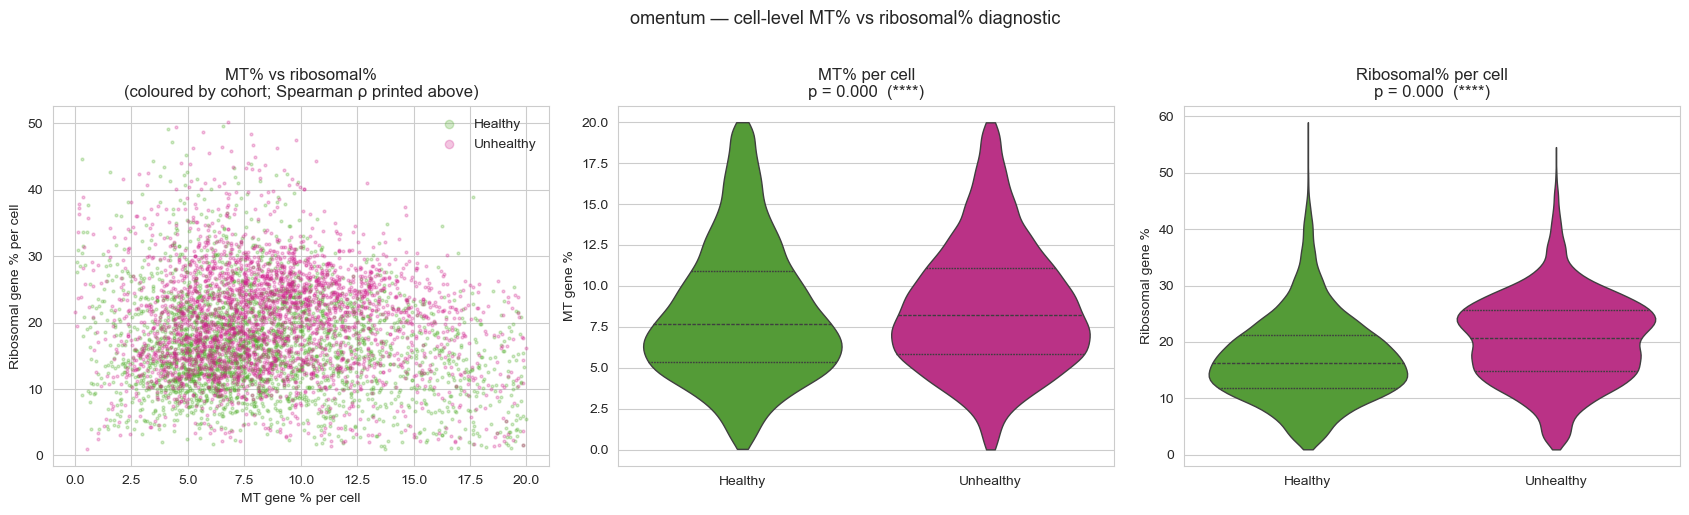


subq | Healthy: MT vs RB  ρ = -0.157  p = 2.49e-18  ****
subq | Unhealthy: MT vs RB  ρ = -0.075  p = 4.30e-09  ****


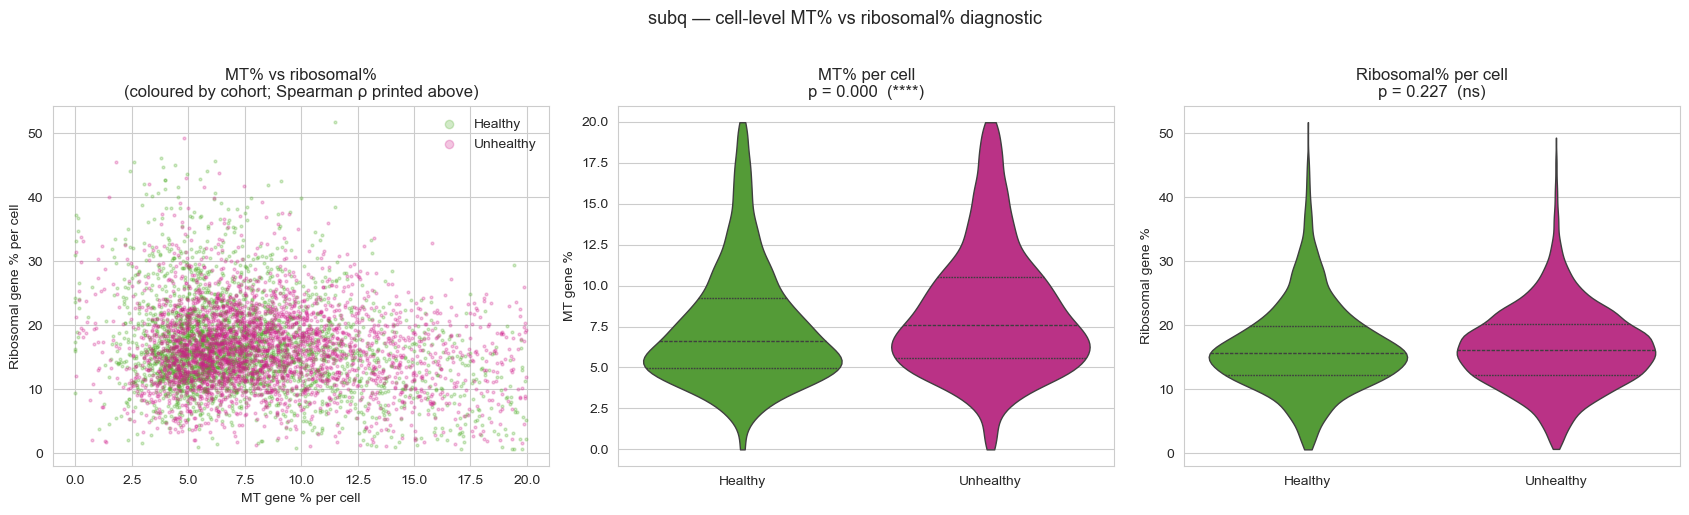

In [6]:
## ── Within-cell MT% vs ribosomal% correlation ─────────────────────────────────
## Key diagnostic: if high-MT cells also have high ribosomal fraction WITHIN
## each cohort, both metrics are driven by the same quality signal (cell damage),
## not by independent biological regulation of OXPHOS vs translation.

N_SAMPLE = 3000   # cells per cohort to plot (scatter would be too dense otherwise)

for tissue, obs in obs_all.items():
    fig, axes = plt.subplots(1, 3, figsize=(17, 5))
    fig.suptitle(f"{tissue} — cell-level MT% vs ribosomal% diagnostic", fontsize=13, y=1.02)

    # ── Panel 1: scatter MT% vs RB% coloured by cohort ──────────────────────
    ax = axes[0]
    for cohort, grp in obs.groupby("cohort"):
        samp = grp.sample(min(N_SAMPLE, len(grp)), random_state=0)
        ax.scatter(samp["pct_counts_mt"], samp["pct_counts_rb"],
                   c=PALETTE[cohort], alpha=0.25, s=4, label=cohort, rasterized=True)
        # Spearman correlation
        r, p = stats.spearmanr(grp["pct_counts_mt"], grp["pct_counts_rb"])
        stars = "****" if p < 0.0001 else "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
        print(f"{tissue} | {cohort}: MT vs RB  ρ = {r:.3f}  p = {p:.2e}  {stars}")

    ax.set_xlabel("MT gene % per cell")
    ax.set_ylabel("Ribosomal gene % per cell")
    ax.set_title("MT% vs ribosomal%\n(coloured by cohort; Spearman ρ printed above)")
    ax.legend(markerscale=3, frameon=False)

    # ── Panel 2: violin of MT% by cohort (cell level) ───────────────────────
    ax = axes[1]
    sns.violinplot(data=obs, x="cohort", y="pct_counts_mt", palette=PALETTE,
                   order=COHORT_ORDER, inner="quartile", cut=0, linewidth=1, ax=ax)
    h = obs.loc[obs.cohort == "Healthy",   "pct_counts_mt"]
    u = obs.loc[obs.cohort == "Unhealthy", "pct_counts_mt"]
    r, p = stats.mannwhitneyu(h, u, alternative="two-sided")
    ax.set_title(f"MT% per cell\n{mwu_label(h, u)}")
    ax.set_xlabel("")
    ax.set_ylabel("MT gene %")

    # ── Panel 3: violin of ribosomal% by cohort ─────────────────────────────
    ax = axes[2]
    sns.violinplot(data=obs, x="cohort", y="pct_counts_rb", palette=PALETTE,
                   order=COHORT_ORDER, inner="quartile", cut=0, linewidth=1, ax=ax)
    h = obs.loc[obs.cohort == "Healthy",   "pct_counts_rb"]
    u = obs.loc[obs.cohort == "Unhealthy", "pct_counts_rb"]
    ax.set_title(f"Ribosomal% per cell\n{mwu_label(h, u)}")
    ax.set_xlabel("")
    ax.set_ylabel("Ribosomal gene %")

    plt.tight_layout()
    plt.show()
    print()